# 🎓 Student Performance Prediction — 01: Exploratory Data Analysis (EDA)

This notebook is the **first step** in the Student Performance Prediction project.

**Goals of this notebook:**
1. Load the raw dataset
2. Inspect its structure and quality
3. Clean and validate the data (handle missing values, duplicates)
4. Explore relationships between features and the target variable (`G3`)
5. Visualize key patterns through professional plots
6. Save cleaned data for use in the next notebook (`02_preprocessing.ipynb`)

---

**Dataset:** [UCI Student Performance Dataset](https://archive.ics.uci.edu/ml/datasets/student+performance)
**Target variable:** `G3` — final grade (0–20 scale)


## 1. Setup & Imports

In [ ]:
# Core libraries
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Allow imports from the src/ folder (project root must be one level up)
import sys
sys.path.append("..")

from src.data_loader import load_data, get_basic_info
from src.preprocessing import add_pass_fail
from src.visualize import plot_grade_distribution, plot_correlation_heatmap

# Configure plot style for consistent, professional visuals
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.figsize"] = (10, 6)

%matplotlib inline

## 2. Load the Dataset

In [ ]:
# Load the dataset
df = load_data("../data/raw/student-mat.csv")

# Preview the first few rows
df.head()

 Dataset loaded successfully: 395 rows, 33 columns


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


## 3. Initial Data Inspection

to understand:
- How many rows and columns we have
- What data types each column has
- Whether there are missing values or duplicate rows

In [ ]:
# Display structured overview of the dataset
get_basic_info(df)

DATASET OVERVIEW
Shape        : (395, 33)
Total cells  : 13035
Missing vals : 0
Duplicates   : 0

Column Data Types:
school        object
sex           object
age            int64
address       object
famsize       object
Pstatus       object
Medu           int64
Fedu           int64
Mjob          object
Fjob          object
reason        object
guardian      object
traveltime     int64
studytime      int64
failures       int64
schoolsup     object
famsup        object
paid          object
activities    object
nursery       object
higher        object
internet      object
romantic      object
famrel         int64
freetime       int64
goout          int64
Dalc           int64
Walc           int64
health         int64
absences       int64
G1             int64
G2             int64
G3             int64
dtype: object

First 5 rows:
  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  ...  \
0     GP   F   18       U     GT3       A     4     4  at_home   teacher  ...   

In [ ]:
# Statistical summary of numerical columns
df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


In [ ]:
# List all column names grouped by data type
print("Numerical columns:")
print(df.select_dtypes(include=[np.number]).columns.tolist())

print("\nCategorical columns:")
print(df.select_dtypes(include=["object"]).columns.tolist())

Numerical columns:
['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']

Categorical columns:
['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']


## 4. Data Cleaning & Handling Missing Values

In [ ]:
# Step 1: Check for missing values per column
missing = df.isnull().sum()
missing = missing[missing > 0]

if missing.empty:
    print(" No missing values found in the dataset.")
else:
    print(" Missing values detected:")
    print(missing)

 No missing values found in the dataset.


In [ ]:
# Step 2: Check for and remove duplicate rows
duplicate_count = df.duplicated().sum()
print(f"Duplicate rows found: {duplicate_count}")

if duplicate_count > 0:
    df = df.drop_duplicates()
    print(f" Duplicates removed. New shape: {df.shape}")
else:
    print(" No duplicate rows to remove.")

Duplicate rows found: 0
 No duplicate rows to remove.


In [ ]:
# Step 3: Validate that grade columns are within the expected 0-20 range
grade_cols = ["G1", "G2", "G3"]

for col in grade_cols:
    out_of_range = df[(df[col] < 0) | (df[col] > 20)]
    print(f"{col}: min={df[col].min()}, max={df[col].max()}, out-of-range rows={len(out_of_range)}")

G1: min=3, max=19, out-of-range rows=0
G2: min=0, max=19, out-of-range rows=0
G3: min=0, max=20, out-of-range rows=0


In [ ]:
# Step 4: Spot-check categorical columns for unexpected values
categorical_cols = df.select_dtypes(include=["object"]).columns

for col in categorical_cols:
    unique_vals = df[col].unique()
    print(f"{col:<12}: {unique_vals}")

school      : ['GP' 'MS']
sex         : ['F' 'M']
address     : ['U' 'R']
famsize     : ['GT3' 'LE3']
Pstatus     : ['A' 'T']
Mjob        : ['at_home' 'health' 'other' 'services' 'teacher']
Fjob        : ['teacher' 'other' 'services' 'health' 'at_home']
reason      : ['course' 'other' 'home' 'reputation']
guardian    : ['mother' 'father' 'other']
schoolsup   : ['yes' 'no']
famsup      : ['no' 'yes']
paid        : ['no' 'yes']
activities  : ['no' 'yes']
nursery     : ['yes' 'no']
higher      : ['yes' 'no']
internet    : ['no' 'yes']
romantic    : ['no' 'yes']


**Conclusion:** The dataset contains **no missing values** and **no duplicate rows**, and all grade values fall within the expected 0–20 range. Categorical columns contain only valid, expected categories. The data is clean and ready for analysis.

## 5. Create the Pass/Fail Target (for Classification)

In [ ]:
# Add the binary pass_fail column
df = add_pass_fail(df, grade_col="G3", threshold=10)

# Preview the new column
df[["G1", "G2", "G3", "pass_fail"]].head()

 Pass/Fail column added. Pass rate: 67.1%


,G1,G2,G3,pass_fail
0,5,6,6,0
1,5,5,6,0
2,7,8,10,1
3,15,14,15,1
4,6,10,10,1


## 6. Target Variable Analysis

**What we're looking for:**
- Is the grade distribution roughly normal, skewed, or multimodal?
- Is there a class imbalance between Pass and Fail students?

 Figure saved: reports/figures/grade_distribution.png


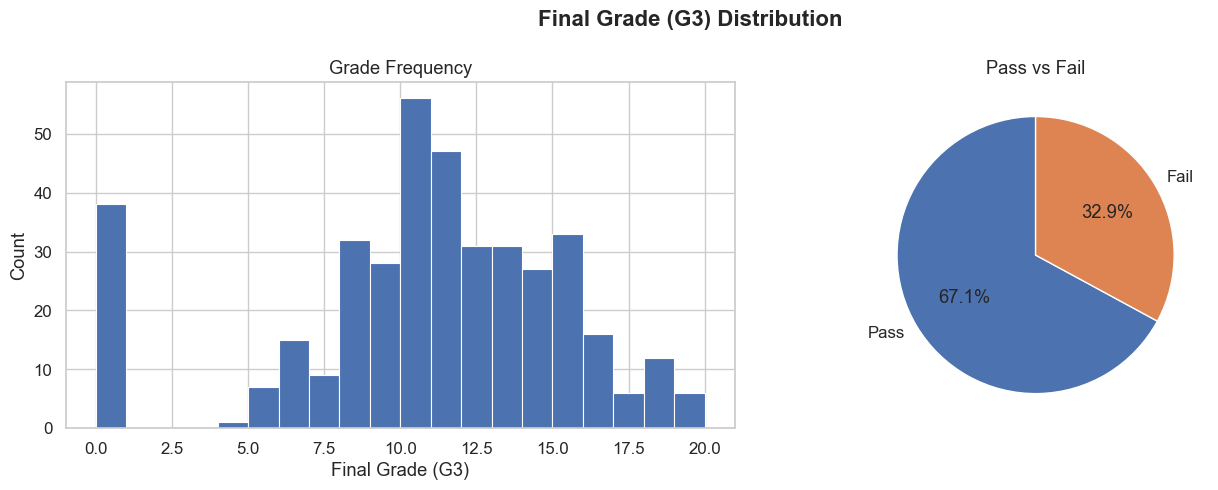

In [ ]:
# Plot the distribution of final grades and pass/fail split
plot_grade_distribution(df, grade_col="G3")

In [ ]:
# Print exact value counts for pass/fail
print(df["pass_fail"].value_counts())
print("\nPass rate: {:.1f}%".format(df["pass_fail"].mean() * 100))

pass_fail
1    265
0    130
Name: count, dtype: int64

Pass rate: 67.1%


**Observation:** The grade distribution is roughly bell-shaped with a notable cluster of students scoring `G3 = 0` (likely students who did not take the final exam or withdrew). The Pass/Fail split shows a reasonable balance, though Fail (G3 < 10) is the minority class — something to keep in mind during model evaluation.

## 7. Numerical Feature Distributions

Visualization for the distributions of key numerical features:
- `age` — Student age
- `studytime` — Weekly study time (1=<2hrs, 2=2-5hrs, 3=5-10hrs, 4=>10hrs)
- `failures` — Number of past class failures
- `absences` — Number of school absences
- `G1`, `G2` — First and second period grades

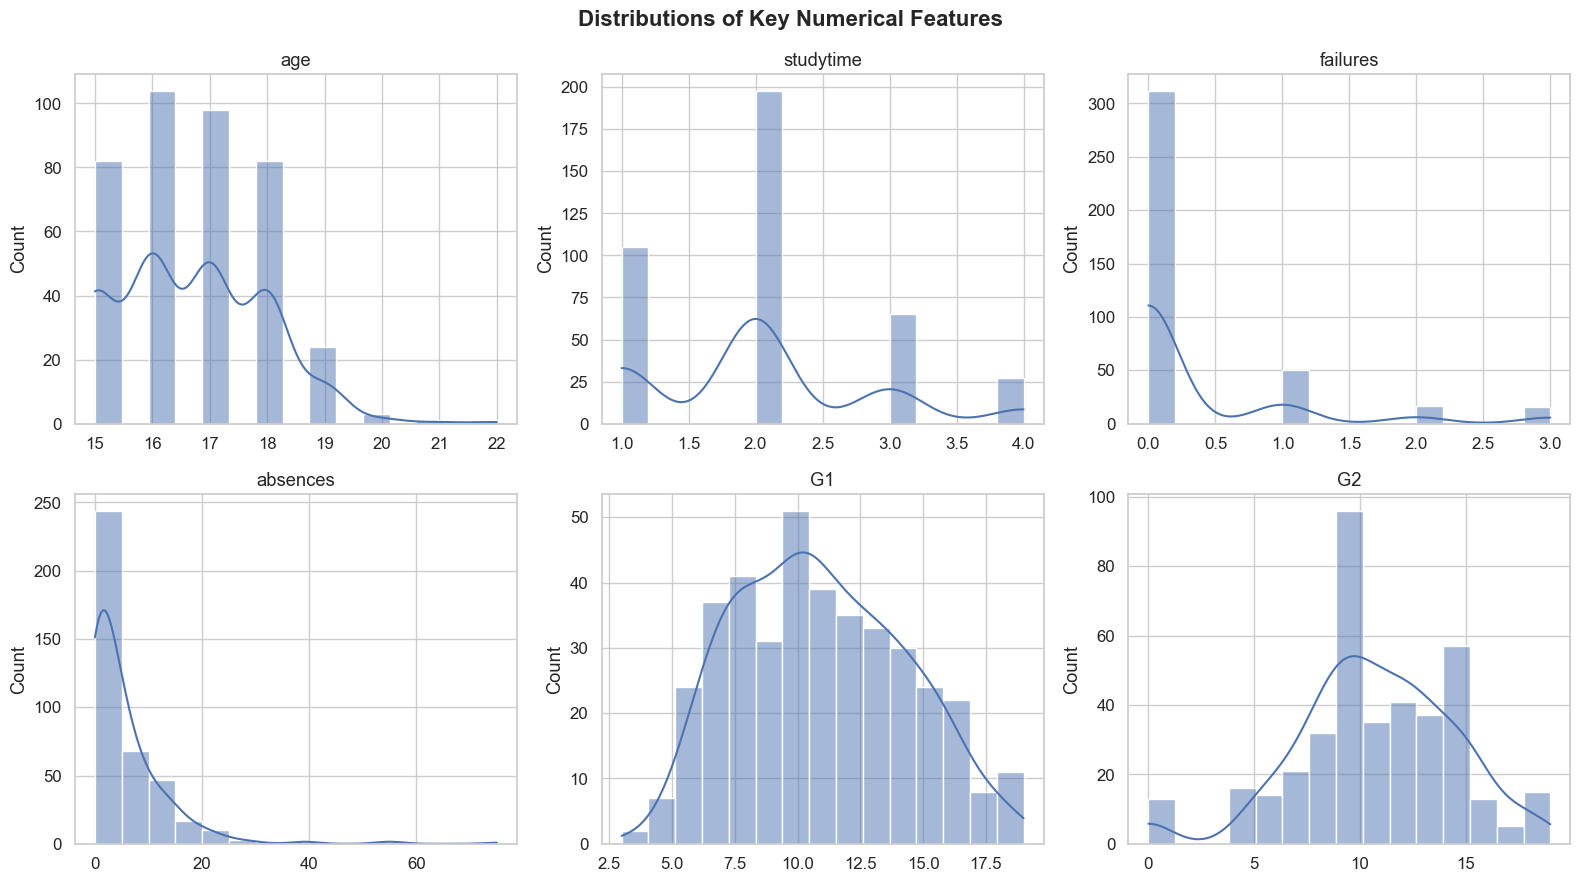

In [ ]:
# Plot histograms for key numerical features
numerical_features = ["age", "studytime", "failures", "absences", "G1", "G2"]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Distributions of Key Numerical Features", fontsize=16, fontweight="bold")

for ax, col in zip(axes.flatten(), numerical_features):
    sns.histplot(df[col], bins=15, kde=True, ax=ax, color="#4C72B0")
    ax.set_title(col)
    ax.set_xlabel("")

plt.tight_layout()
plt.savefig("../reports/figures/numerical_distributions.png", bbox_inches="tight", dpi=150)
plt.show()

**Observations:**
- `absences` is heavily right-skewed — most students have few absences, but some have many
- `failures` shows most students have **zero** past failures
- `G1` and `G2` are roughly normally distributed and closely resemble each other (and `G3`), suggesting strong predictive power for the final grade

## 8. Correlation Analysis

Now we examine how numerical features correlate with each other and, most importantly, with our target variable `G3`.

A correlation heatmap helps us:
- Identify features strongly related to the final grade
- Spot multicollinearity between features (which we may need to address during preprocessing)

 Figure saved: reports/figures/correlation_heatmap.png


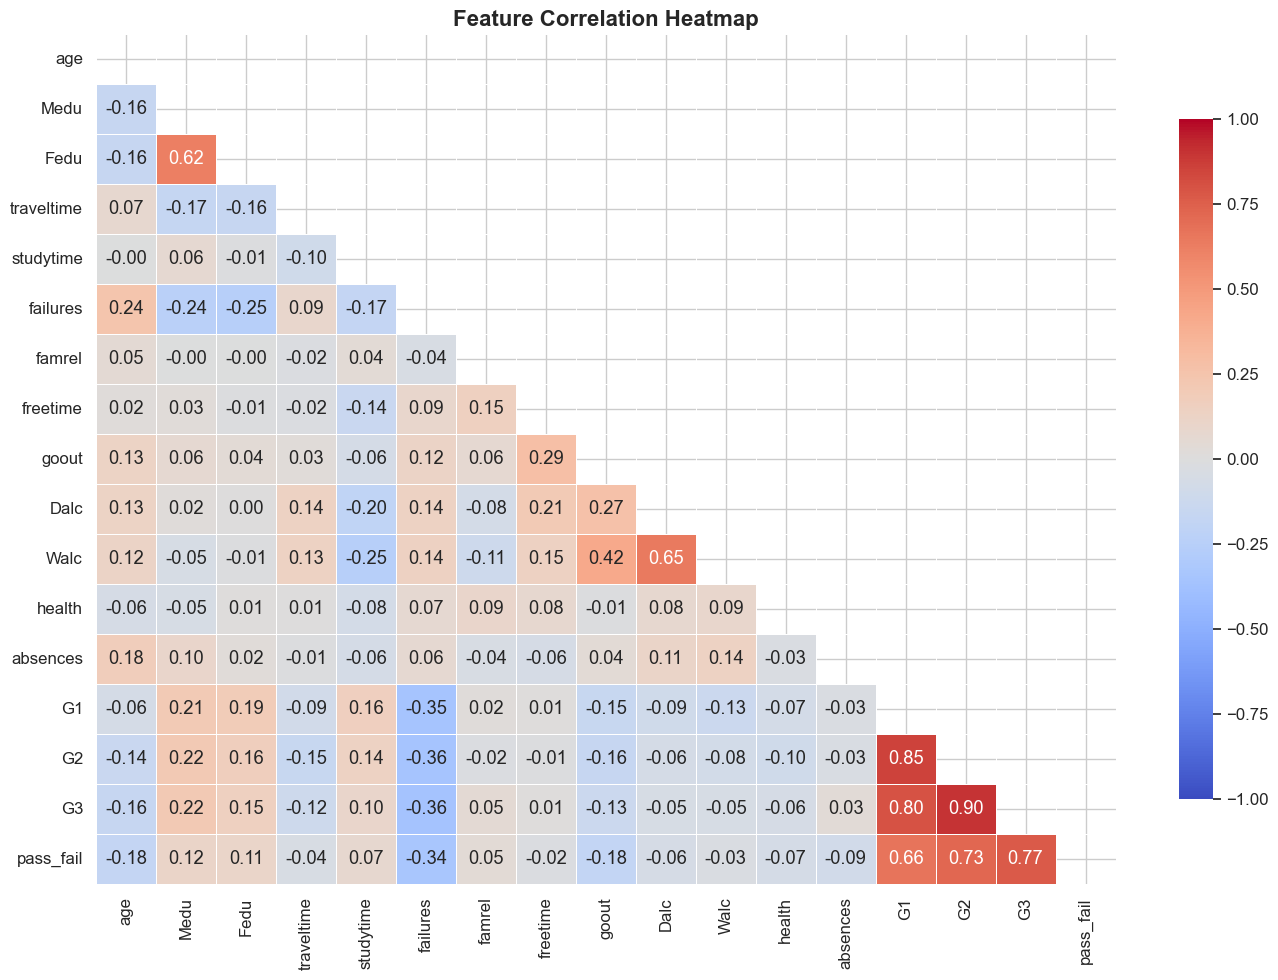

In [ ]:
# Plot correlation heatmap of numerical features
plot_correlation_heatmap(df)

In [ ]:
# Print the features most correlated with G3 (final grade)
numeric_df = df.select_dtypes(include=[np.number])
correlations = numeric_df.corr()["G3"].sort_values(ascending=False)

print("Top correlations with G3 (Final Grade):\n")
print(correlations)

Top correlations with G3 (Final Grade):

G3            1.000000
G2            0.904868
G1            0.801468
pass_fail     0.770042
Medu          0.217147
Fedu          0.152457
studytime     0.097820
famrel        0.051363
absences      0.034247
freetime      0.011307
Walc         -0.051939
Dalc         -0.054660
health       -0.061335
traveltime   -0.117142
goout        -0.132791
age          -0.161579
failures     -0.360415
Name: G3, dtype: float64


**Key Insight:** As expected, `G1` and `G2` (first and second period grades) show the **strongest correlation** with `G3`. This makes sense — past performance is a strong predictor of future performance. `failures` shows a notable **negative correlation**, while `studytime` and parental education levels (`Medu`, `Fedu`) show weaker positive correlations.

## 9. Categorical Feature Analysis

Boxplots was applied to compare the distribution of `G3` across different categories, to explain how categorical features relate to student performance.

**Features explored:**
- `sex` — Student gender
- `school` — School attended
- `internet` — Internet access at home
- `romantic` — In a romantic relationship
- `higher` — Wants to pursue higher education
- `schoolsup` — Extra educational school support

C:\Users\Fatma Nagim\AppData\Local\Temp\ipykernel_25320\2889712140.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y="G3", ax=ax, palette="muted")
C:\Users\Fatma Nagim\AppData\Local\Temp\ipykernel_25320\2889712140.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y="G3", ax=ax, palette="muted")
C:\Users\Fatma Nagim\AppData\Local\Temp\ipykernel_25320\2889712140.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y="G3", ax=ax, palette="muted")
C:\Users\Fatma Nagim\AppData\Local\Temp\ipyker

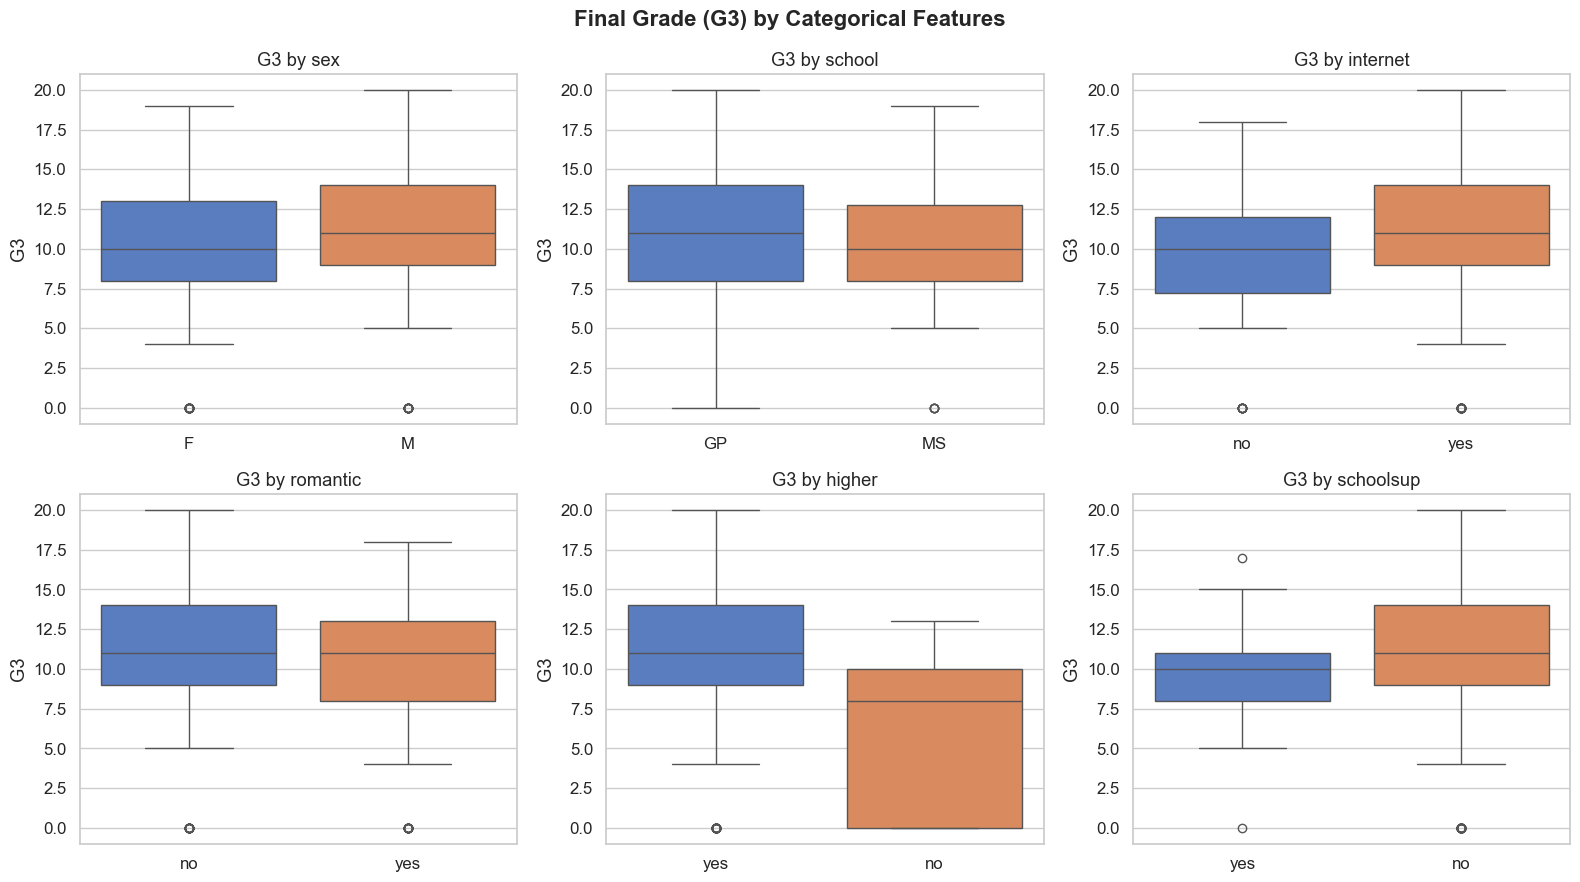

In [16]:
# Boxplots: Categorical features vs Final Grade (G3)
categorical_features = ["sex", "school", "internet", "romantic", "higher", "schoolsup"]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Final Grade (G3) by Categorical Features", fontsize=16, fontweight="bold")

for ax, col in zip(axes.flatten(), categorical_features):
    sns.boxplot(data=df, x=col, y="G3", ax=ax, palette="muted")
    ax.set_title(f"G3 by {col}")
    ax.set_xlabel("")

plt.tight_layout()
plt.savefig("../reports/figures/categorical_vs_grade.png", bbox_inches="tight", dpi=150)
plt.show()


**Observations:**
- Students who want to pursue **higher education** (`higher = yes`) show notably higher final grades — a strong signal of motivation
- Students receiving **extra school support** (`schoolsup = yes`) tend to have slightly lower grades, likely because this support is targeted at students who are already struggling
- Differences across `sex` and `school` are relatively modest
- Students in romantic relationships show a slight tendency toward lower grades

## 10. Study Time & Failures vs. Final Grade

These two features are commonly cited as strong academic performance indicators.

C:\Users\Fatma Nagim\AppData\Local\Temp\ipykernel_25320\3511582848.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="studytime", y="G3", ax=axes[0], palette="Blues")
C:\Users\Fatma Nagim\AppData\Local\Temp\ipykernel_25320\3511582848.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="failures", y="G3", ax=axes[1], palette="Reds")


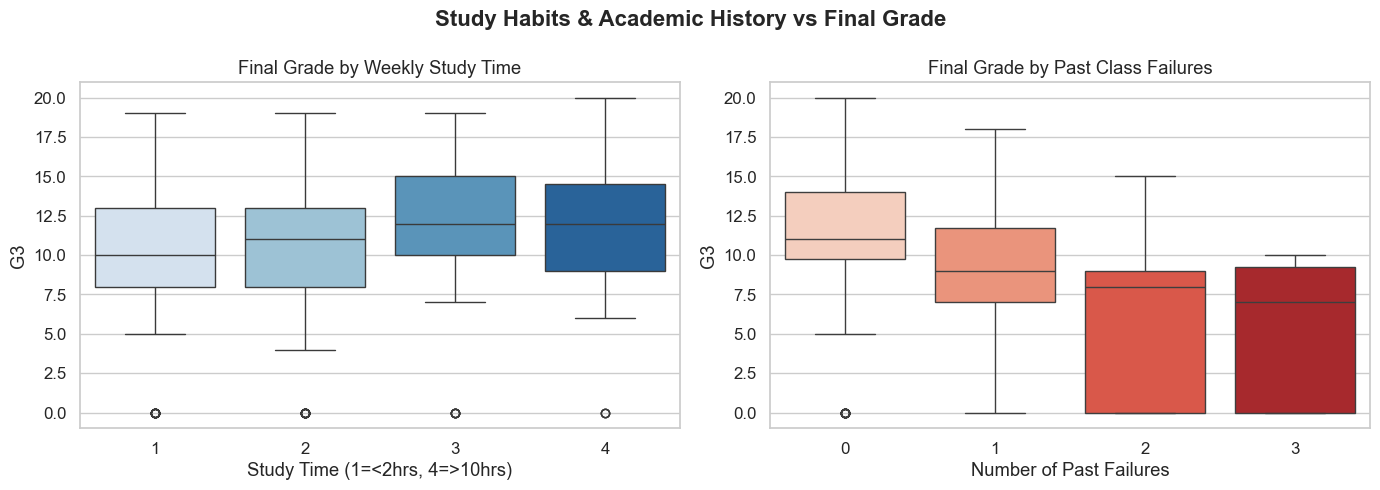

In [17]:
# Study time vs Final Grade
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Study Habits & Academic History vs Final Grade", fontsize=16, fontweight="bold")

sns.boxplot(data=df, x="studytime", y="G3", ax=axes[0], palette="Blues")
axes[0].set_title("Final Grade by Weekly Study Time")
axes[0].set_xlabel("Study Time (1=<2hrs, 4=>10hrs)")

sns.boxplot(data=df, x="failures", y="G3", ax=axes[1], palette="Reds")
axes[1].set_title("Final Grade by Past Class Failures")
axes[1].set_xlabel("Number of Past Failures")

plt.tight_layout()
plt.savefig("../reports/figures/studytime_failures_vs_grade.png", bbox_inches="tight", dpi=150)
plt.show()


**Observations:**
- There's a **clear positive trend**: more study time generally corresponds to higher final grades
- Past **failures show a strong negative relationship** with final grades — students with 1+ past failures score noticeably lower on average than those with zero failures

## 11. Lifestyle Factors: Alcohol Consumption vs Grades

C:\Users\Fatma Nagim\AppData\Local\Temp\ipykernel_25320\4014724326.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Dalc", y="G3", ax=axes[0], palette="YlOrRd")
C:\Users\Fatma Nagim\AppData\Local\Temp\ipykernel_25320\4014724326.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Walc", y="G3", ax=axes[1], palette="YlOrRd")


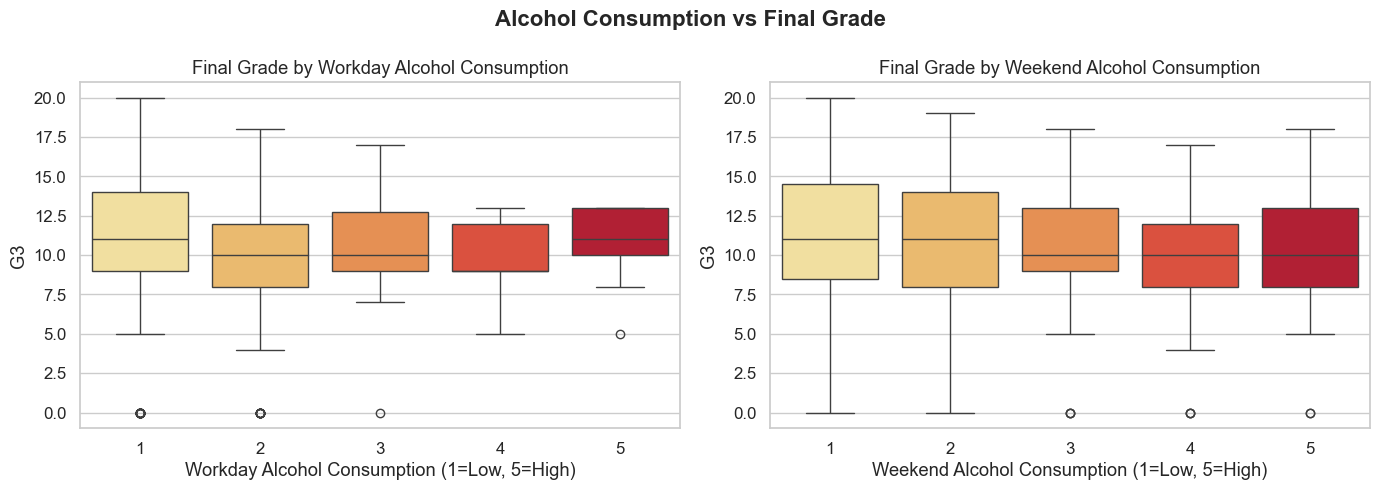

In [ ]:
# Alcohol consumption vs Final Grade
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Alcohol Consumption vs Final Grade", fontsize=16, fontweight="bold")

sns.boxplot(data=df, x="Dalc", y="G3", ax=axes[0], palette="YlOrRd")
axes[0].set_title("Final Grade by Workday Alcohol Consumption")
axes[0].set_xlabel("Workday Alcohol Consumption (1=Low, 5=High)")

sns.boxplot(data=df, x="Walc", y="G3", ax=axes[1], palette="YlOrRd")
axes[1].set_title("Final Grade by Weekend Alcohol Consumption")
axes[1].set_xlabel("Weekend Alcohol Consumption (1=Low, 5=High)")

plt.tight_layout()
plt.savefig("../reports/figures/alcohol_vs_grade.png", bbox_inches="tight", dpi=150)
plt.show()

**Observation:** There is a mild downward trend in final grades as alcohol consumption increases, particularly for workday consumption (`Dalc`). The effect is more pronounced at the highest consumption levels, though sample sizes for those groups are small.

## 12. Save Cleaned Dataset

Finally, we save the cleaned dataset (with the new `pass_fail` column added) to `data/processed/` so it can be used directly in the next notebook: **`02_preprocessing.ipynb`**.

In [ ]:
# Save the cleaned dataset for the next stage of the pipeline
output_path = "../data/processed/student_clean.csv"
df.to_csv(output_path, index=False)

print(f" Cleaned dataset saved to: {output_path}")
print(f"Final shape: {df.shape}")

 Cleaned dataset saved to: ../data/processed/student_clean.csv
Final shape: (395, 34)


## 13. Summary of Key Findings

| Finding | Insight |
|---|---|
| **No missing values / duplicates** | Dataset is clean and analysis-ready |
| **G1, G2 strongly predict G3** | Past grades are the strongest predictors of final performance |
| **Failures negatively impact grades** | Students with past failures score significantly lower |
| **Study time correlates positively** | More weekly study time → higher grades |
| **Higher education aspiration matters** | Students aiming for higher education outperform peers |
| **Alcohol consumption has mild negative effect** | Especially on workdays, at high consumption levels |
| **Pass rate** | The majority of students pass (G3 ≥ 10), with some class imbalance |

---

### ➡️ Next Step
Proceed to **`02_preprocessing.ipynb`** to encode categorical variables, scale features, and prepare train/test splits for modeling.